# Volve 5 — integrated field twin, history, constraints, uncertainty, and decisions

**Notebook 5 of 5 — integrated Volve field evaluation**

The authoritative input boundary is Equinor's Volve Data Village
listing in Databricks Marketplace. The notebook can read an
installed Unity Catalog volume directly or securely download only
selected files into Colab. It never stores credentials or
redistributes the complete Volve package.

A deterministic teaching fixture is used during unauthenticated
clean-runtime validation. Every such result is marked
**DEMONSTRATION_FALLBACK** and must not be described as measured
Volve data, a history match, a reserves statement, or certified
design.


## Learning outcomes and engineering decisions

            - assemble all discipline handoffs without losing source or units
- reconcile measured history with reservoir, well, network, and facility states
- identify the active constraint and deferred production through time
- evaluate interventions, availability, economics, emissions, and uncertainty
- separate model calibration, forecast, decision, and assurance evidence
- produce an auditable field evaluation and next-data acquisition plan

            The discipline result is written as a versioned handoff contract.
            Downstream notebooks consume quantities with names, units, source
            mode, assumptions, uncertainty, and validity limits rather than
            relying on hidden notebook state.


## End-to-end architecture

The series follows one controlled chain:

**Marketplace assets → seismic and logs → static model → PVT and
reservoir forecast → well and SURF deliverability → facilities and
export constraints → field scenarios and decisions**

Specialist tools retain their roles. segyio handles SEG-Y, lasio
and dlisio handle logs, OPM Flow or its deck interface handles
dynamic reservoir simulation, resdata inspects OPM results, and
NeqSim owns fluid characterization, PVT, flow assurance, process
simulation, equipment duties, and composable surface streams.


## Data provenance, licence, and claim boundary

Primary sources:

- [Databricks Marketplace: Equinor Volve Data Village](https://marketplace.databricks.com/details/5c3558ef-315c-44dd-baef-7062ac301f22/Equinor-ASA_Volve-Data-Village)
- [Equinor Volve data sharing](https://www.equinor.com/energy/volve-data-sharing)
- [Equinor Volve data licence](https://www.equinor.com/content/dam/statoil/documents/what-we-do/Equinor-HRS-Terms-and-conditions-for-licence-to-data-Volve.pdf)
- [Databricks Marketplace access guidance](https://docs.databricks.com/aws/en/marketplace/get-started-consumer)
- [Databricks Files API for Unity Catalog volumes](https://docs.databricks.com/aws/en/volumes/volume-files)

The raw package remains in the user's read-only Marketplace share.
Generated working tables contain only selected or derived values
and retain the source path and digest when real files are used.


## Clean-runtime setup and NeqSim source policy

Normal Colab execution clones current equinor/neqsim master,
records the resolved commit, builds the runtime JAR, adds it to the
JVM before importing NeqSim, and verifies the loaded class origin.
The Python package remains the JPype bridge. Local validation can
set VOLVE_VALIDATION_MODE=1 to use the pinned 3.17.0 release JAR;
that mode validates notebook logic but does not replace the
required current-master and Databricks acceptance run.


In [1]:
import importlib.util
from importlib.metadata import PackageNotFoundError, version
import hashlib
import os
from pathlib import Path
import platform
import shutil
import subprocess
import sys


VALIDATION_MODE = os.environ.get("VOLVE_VALIDATION_MODE") == "1"
NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
NEQSIM_REPOSITORY_URL = "https://github.com/equinor/neqsim"

if not VALIDATION_MODE:
    required = {
        "neqsim": "3.17.0",
        "databricks-sdk": "0.72.0",
        "segyio": "1.9.14",
        "lasio": "0.32",
        "dlisio": "1.0.3",
    }
    specifications = [
        f"{package}=={required_version}"
        for package, required_version in required.items()
    ]
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", *specifications],
        check=True,
        timeout=900,
    )
    source_dir = Path("/content/neqsim-master")
    if not source_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                NEQSIM_SOURCE_REF,
                NEQSIM_REPOSITORY_URL,
                str(source_dir),
            ],
            check=True,
            timeout=300,
        )
    resolved_commit = subprocess.run(
        ["git", "-C", str(source_dir), "rev-parse", "HEAD"],
        capture_output=True,
        check=True,
        text=True,
        timeout=60,
    ).stdout.strip()
    subprocess.run(
        [str(source_dir / "mvnw"), "-q", "-DskipTests", "package"],
        check=True,
        cwd=source_dir,
        timeout=1800,
    )
    runtime_jars = sorted((source_dir / "target").glob("neqsim-*-jar-with-dependencies.jar"))
    if not runtime_jars:
        raise RuntimeError("Current-master NeqSim runtime JAR was not built.")
    os.environ["NEQSIM_JVM_AUTOSTART"] = "false"
    import jpype

    jpype.addClassPath(str(runtime_jars[-1]))
    jpype.startJVM(convertStrings=False)
else:
    resolved_commit = "release-3.17.0-validation-runtime"

from neqsim import jneqsim
from neqsim.thermo import TPflash

protection = (
    jneqsim.thermo.system.SystemSrkEos.class_
    .getProtectionDomain()
    .getCodeSource()
)
runtime_origin = str(protection.getLocation()) if protection else "bundled JAR"
print(
    {
        "Python": platform.python_version(),
        "NeqSim bridge": version("neqsim"),
        "source ref": NEQSIM_SOURCE_REF,
        "resolved commit": resolved_commit,
        "runtime origin": runtime_origin,
        "validation mode": VALIDATION_MODE,
    }
)


{'Python': '3.12.13', 'NeqSim bridge': '3.17.0', 'source ref': 'master', 'resolved commit': 'release-3.17.0-validation-runtime', 'runtime origin': 'None', 'validation mode': True}


In [2]:
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

series_dir = Path.cwd()
if not (series_dir / "volve_common.py").is_file():
    repository_dir = Path("/content/NeqSim-Colab")
    if not repository_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "https://github.com/EvenSol/NeqSim-Colab.git",
                str(repository_dir),
            ],
            check=True,
            timeout=300,
        )
    series_dir = (
        repository_dir
        / "notebooks"
        / "fielddevelopment"
        / "volve"
    )
sys.path.insert(0, str(series_dir))

import volve_common as vc

work_dir = Path(
    os.environ.get("VOLVE_WORK_DIR", str(series_dir / "work"))
)
work_dir.mkdir(parents=True, exist_ok=True)
source = vc.resolve_source()
display(vc.source_table(source))


,item,value
0,resolved mode,demonstration-fallback
1,Marketplace listing,https://marketplace.databricks.com/details/5c3...
2,volume root,not mounted
3,credentials,none
4,measured Volve data loaded,False
5,claim boundary,Deterministic teaching fixtures are used. Resu...


## Marketplace ingestion and bounded file selection

The listing contains tables and non-tabular files. Large SEG-Y,
DLIS, Eclipse restart, and report assets are normally shared as
Unity Catalog volume files. Colab therefore uses the Databricks
Files API and downloads only paths selected for the calculation.
The complete 5 TB-scale package is never copied.

Set VOLVE_DATA_MODE=marketplace and either:

1. point VOLVE_VOLUME_ROOT to an existing mounted or exported
   Marketplace directory; or
2. set VOLVE_REMOTE_VOLUME_ROOT to the Unity Catalog volume path and
   store DATABRICKS_HOST and DATABRICKS_TOKEN as Colab secrets.


In [3]:
if source.mode == "marketplace-local-volume":
    inventory = vc.inventory_local_volume(Path(source.volume_root))
elif source.mode == "marketplace-remote-volume":
    inventory = vc.list_remote_directory(source.volume_root)
else:
    inventory = vc.demonstration_inventory()

domain_summary = (
    inventory.groupby("domain", as_index=False)
    .agg(file_count=("relative_path", "size"), bytes=("bytes", "sum"))
    .sort_values("bytes", ascending=False)
)
domain_summary["size_GB"] = domain_summary["bytes"] / 1.0e9
display(domain_summary[["domain", "file_count", "size_GB"]])
display(inventory.head(12))


,domain,file_count,size_GB
4,seismic,1,3.20000
3,reservoir-model,3,2.91180
6,well-log,2,0.32420
5,static-model,1,0.00850
0,facilities-document,1,0.00530
1,production-history,1,0.00240
7,well-trajectory,1,0.00064
2,pvt,1,0.00012


,relative_path,suffix,bytes,domain
0,Seismic/ST0202/stacked_volume.sgy,.sgy,3200000000,seismic
1,Well_logs/15_9-F-1_C/composite.las,.las,4200000,well-log
2,Well_logs/15_9-F-14/formation_eval.dlis,.dlis,320000000,well-log
3,Reservoir_model/VOLVE.DATA,.data,1800000,reservoir-model
4,Reservoir_model/VOLVE.EGRID,.egrid,210000000,reservoir-model
5,Reservoir_model/VOLVE.UNRST,.unrst,2700000000,reservoir-model
6,Production/volve_daily_production.xlsx,.xlsx,2400000,production-history
7,Wells/well_trajectories.csv,.csv,640000,well-trajectory
8,PVT/representative_fluid_composition.xlsx,.xlsx,120000,pvt
9,Static_model/top_hugin_surface.txt,.txt,8500000,static-model


## 1. Handoff registry and lineage

The field twin is a graph of models, evidence, and contracts—not one
monolithic simulator. Each handoff is checked for schema version,
source mode, units, generation time, and limitations. A real
measured-data evaluation must reject mixtures of fallback and
Marketplace results unless the distinction is explicit.


In [4]:
contract_files = [
    work_dir / "01_geoscience_static_model.json",
    work_dir / "02_pvt_reservoir_forecast.json",
    work_dir / "03_wells_surf_envelope.json",
    work_dir / "04_facilities_capacity_emissions.json",
]
contract_registry = []
for contract_file in contract_files:
    if contract_file.is_file():
        contract = vc.read_contract(contract_file)
        contract_registry.append(
            {
                "path": contract_file.name,
                "discipline": contract.get("discipline"),
                "schema_version": contract.get("schema_version"),
                "source_mode": contract.get("source", {}).get("mode"),
                "generated_at_utc": contract.get("generated_at_utc"),
            }
        )
registry_table = pd.DataFrame(contract_registry)
display(registry_table)


,path,discipline,schema_version,source_mode,generated_at_utc
0,01_geoscience_static_model.json,geoscience-and-static-model,1.0,demonstration-fallback,2026-08-15T08:56:06.164069+00:00
1,02_pvt_reservoir_forecast.json,pvt-and-reservoir,1.0,demonstration-fallback,2026-08-15T08:56:16.269663+00:00
2,03_wells_surf_envelope.json,wells-surf-flow-assurance,1.0,demonstration-fallback,2026-08-15T08:56:24.025874+00:00
3,04_facilities_capacity_emissions.json,facilities-processing,1.0,demonstration-fallback,2026-08-15T08:56:36.948652+00:00


## 2. Historical field data and model state alignment

Rates, pressures, interventions, well status, and facility events
occur on different clocks. The field twin uses an explicit monthly
reporting axis and preserves whether each value is observed,
allocated, simulated, estimated, or assumed. The fallback history
illustrates the join and derived KPIs.


In [5]:
production = vc.demo_production_history()
field = vc.reservoir_screen(production)
field["active_wells"] = (
    production.loc[production["oil_rate_Sm3_day"].gt(1.0)]
    .groupby("date")["well"]
    .nunique()
    .reindex(field["date"], fill_value=0)
    .to_numpy()
)
field["liquid_rate_Sm3_day"] = (
    field["oil_rate_Sm3_day"] + field["water_rate_Sm3_day"]
)
field["gross_revenue_MUSD_month"] = (
    field["oil_rate_Sm3_day"] * 30.4375 * 6.2898 * 75.0 / 1.0e6
    + field["gas_rate_Sm3_day"] * 30.4375 * 0.32 / 1.0e6
)
display(field.head())
display(field.tail())


,date,oil_rate_Sm3_day,gas_rate_Sm3_day,water_rate_Sm3_day,liquid_rate_Sm3_day,water_cut_fraction,gor_Sm3_Sm3,elapsed_days,cumulative_oil_MSm3,cumulative_water_MSm3,average_pressure_bara,recovery_fraction,active_wells,gross_revenue_MUSD_month
0,2008-02-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,265.000000,0.000000,0,0.000000
1,2008-03-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,29,0.000000,0.000000,265.000000,0.000000,0,0.000000
2,2008-04-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60,0.000000,0.000000,265.000000,0.000000,0,0.000000
3,2008-05-01,199.020090,23896.122612,18.971926,217.992016,0.087030,120.068897,90,0.006058,0.000577,264.938128,0.000418,1,3.090365
4,2008-06-01,402.739247,48360.148968,38.745789,441.485036,0.087762,120.078064,121,0.018316,0.001757,264.812939,0.001263,1,6.253733


,date,oil_rate_Sm3_day,gas_rate_Sm3_day,water_rate_Sm3_day,liquid_rate_Sm3_day,water_cut_fraction,gor_Sm3_Sm3,elapsed_days,cumulative_oil_MSm3,cumulative_water_MSm3,average_pressure_bara,recovery_fraction,active_wells,gross_revenue_MUSD_month
99,2016-05-01,746.471374,169026.405922,4087.995185,4834.466558,0.845594,226.433875,3012,5.276656,5.234186,217.610908,0.363907,5,12.364477
100,2016-06-01,744.537911,168891.162834,4119.215467,4863.753378,0.846921,226.840246,3043,5.299318,5.359565,217.548870,0.365470,5,12.335398
101,2016-07-01,741.245014,168414.090529,4139.824396,4881.069410,0.848139,227.204349,3073,5.321880,5.485571,217.488732,0.367026,5,12.283471
102,2016-08-01,735.972114,167455.394098,4146.194990,4882.167103,0.849253,227.529537,3104,5.344281,5.611770,217.430521,0.368571,5,12.198423
103,2016-09-01,728.261759,165911.928352,4135.564656,4863.826416,0.850270,227.819086,3135,5.366447,5.737647,217.374292,0.370100,5,12.072681


## 3. Constraint graph and deliverability

At each time, the delivered oil rate is

$$q_o=\min(q_{o,\mathrm{reservoir}},q_{o,\mathrm{well}},q_{o,\mathrm{SURF}},q_{o,\mathrm{facility}},q_{o,\mathrm{export}})$$

Similar constraints apply to gas, liquids, water, power, and
emissions. A useful model records the limiting node and the gap to
the next constraint so debottlenecking does not merely move the
problem without value.


In [6]:
month_index = np.arange(len(field))
reservoir_potential = field["oil_rate_Sm3_day"].to_numpy() * 1.12
well_capacity = 4700.0 * np.exp(-0.0032 * month_index)
surf_capacity = np.full(len(field), 4400.0)
facility_capacity = np.full(len(field), 4100.0)
export_capacity = np.where(
    (field["date"].dt.month == 9) & (field["date"].dt.year % 3 == 0),
    2600.0,
    4300.0,
)
capacity_matrix = np.column_stack(
    [
        reservoir_potential,
        well_capacity,
        surf_capacity,
        facility_capacity,
        export_capacity,
    ]
)
constraint_names = np.array(
    ["reservoir", "wells", "SURF", "facility", "export"]
)
limiting_index = np.argmin(capacity_matrix, axis=1)
delivered_oil = capacity_matrix[np.arange(len(field)), limiting_index]
field["unconstrained_oil_Sm3_day"] = reservoir_potential
field["integrated_capacity_Sm3_day"] = delivered_oil
field["active_constraint"] = constraint_names[limiting_index]
field["deferred_oil_Sm3_day"] = np.maximum(
    reservoir_potential - delivered_oil,
    0.0,
)
display(
    field[
        [
            "date",
            "unconstrained_oil_Sm3_day",
            "integrated_capacity_Sm3_day",
            "active_constraint",
            "deferred_oil_Sm3_day",
        ]
    ].head(12)
)


,date,unconstrained_oil_Sm3_day,integrated_capacity_Sm3_day,active_constraint,deferred_oil_Sm3_day
0,2008-02-01,0.000000,0.000000,reservoir,0.0
1,2008-03-01,0.000000,0.000000,reservoir,0.0
2,2008-04-01,0.000000,0.000000,reservoir,0.0
3,2008-05-01,222.902501,222.902501,reservoir,0.0
4,2008-06-01,451.067957,451.067957,reservoir,0.0
5,2008-07-01,681.912248,681.912248,reservoir,0.0
6,2008-08-01,912.411030,912.411030,reservoir,0.0
7,2008-09-01,1348.783773,1348.783773,reservoir,0.0
8,2008-10-01,1525.585808,1525.585808,reservoir,0.0
9,2008-11-01,1692.402619,1692.402619,reservoir,0.0


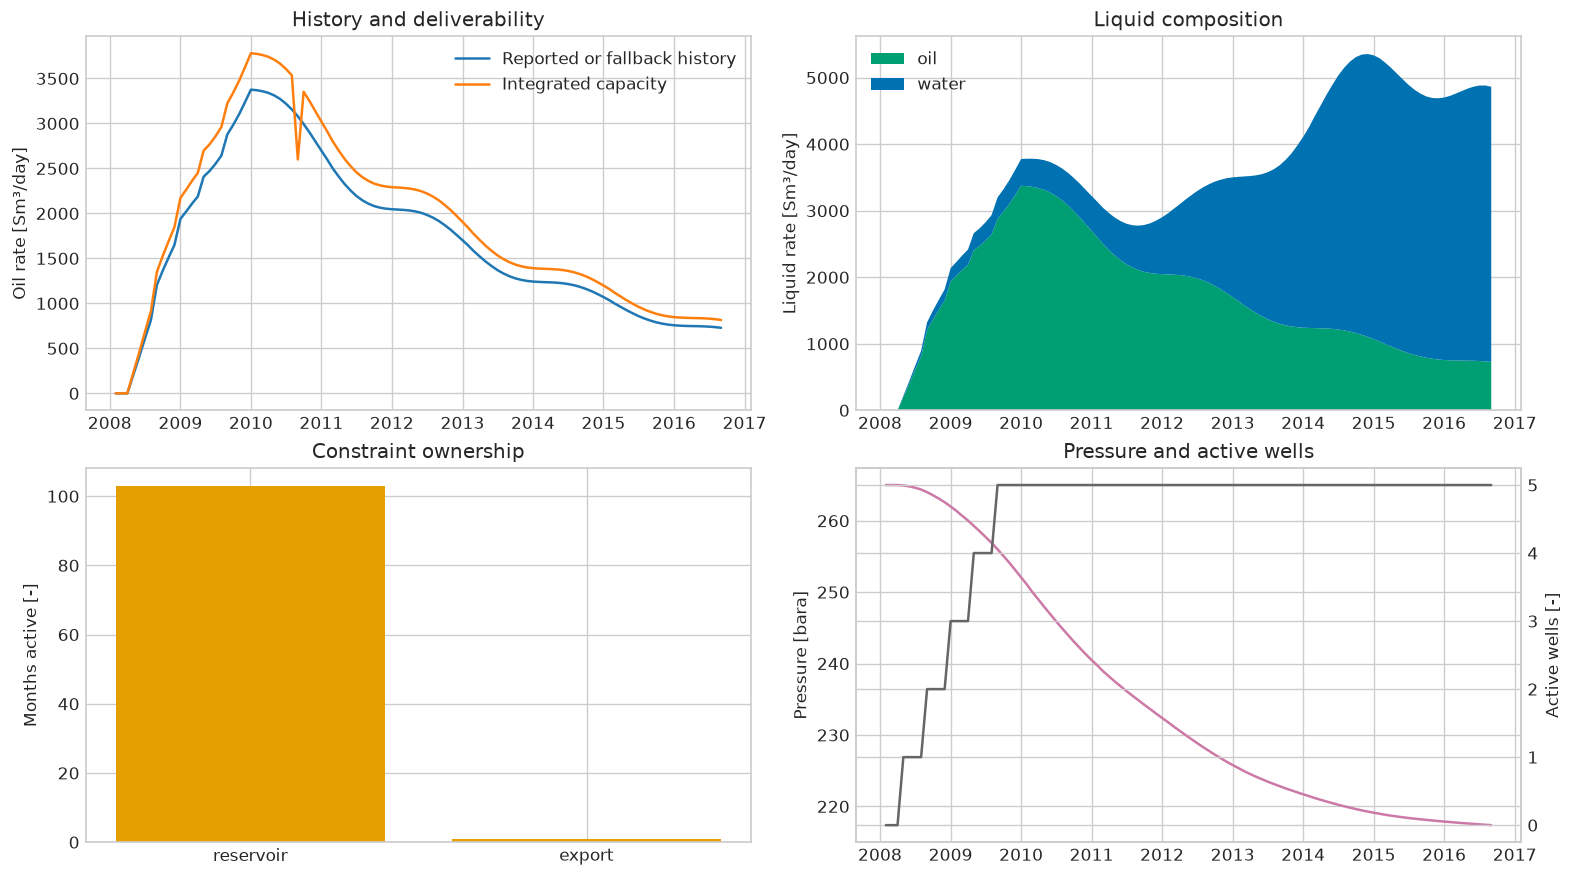

In [7]:
integrated_figure, integrated_axes = plt.subplots(
    2,
    2,
    figsize=(13.0, 7.2),
    constrained_layout=True,
)
integrated_axes[0, 0].plot(
    field["date"],
    field["oil_rate_Sm3_day"],
    label="Reported or fallback history",
)
integrated_axes[0, 0].plot(
    field["date"],
    field["integrated_capacity_Sm3_day"],
    label="Integrated capacity",
)
integrated_axes[0, 0].set(
    ylabel="Oil rate [Sm³/day]",
    title="History and deliverability",
)
integrated_axes[0, 0].legend()
integrated_axes[0, 1].stackplot(
    field["date"],
    field["oil_rate_Sm3_day"],
    field["water_rate_Sm3_day"],
    labels=["oil", "water"],
    colors=["#009E73", "#0072B2"],
)
integrated_axes[0, 1].set(
    ylabel="Liquid rate [Sm³/day]",
    title="Liquid composition",
)
integrated_axes[0, 1].legend()
constraint_counts = field["active_constraint"].value_counts()
integrated_axes[1, 0].bar(
    constraint_counts.index,
    constraint_counts.values,
    color="#E69F00",
)
integrated_axes[1, 0].set(
    ylabel="Months active [-]",
    title="Constraint ownership",
)
integrated_axes[1, 1].plot(
    field["date"],
    field["average_pressure_bara"],
    color="#CC79A7",
    label="Reservoir pressure",
)
integrated_axes[1, 1].set(
    ylabel="Pressure [bara]",
    title="Pressure and active wells",
)
secondary_axis = integrated_axes[1, 1].twinx()
secondary_axis.plot(
    field["date"],
    field["active_wells"],
    color="#666666",
    label="Active wells",
)
secondary_axis.set_ylabel("Active wells [-]")
plt.show()


## 4. Model-versus-measurement diagnostics

Residuals should be segmented by well, phase, operating regime,
allocation status, intervention, and active constraint. A low total
RMSE can hide systematic water breakthrough timing, GOR response,
downtime, or one poorly represented well. The demonstration creates
a transparent model perturbation and reports residual statistics.


In [8]:
model_oil = field["integrated_capacity_Sm3_day"].to_numpy(copy=True)
model_oil *= 0.97 + 0.04 * np.sin(month_index / 9.0)
observed_oil = field["oil_rate_Sm3_day"].to_numpy()
residual = model_oil - observed_oil
active_mask = observed_oil > 1.0
diagnostics = pd.DataFrame(
    {
        "metric": ["bias", "MAE", "RMSE", "P90 absolute residual"],
        "value_Sm3_day": [
            residual[active_mask].mean(),
            np.abs(residual[active_mask]).mean(),
            np.sqrt(np.mean(residual[active_mask] ** 2)),
            np.quantile(np.abs(residual[active_mask]), 0.9),
        ],
    }
)
display(diagnostics)


,metric,value_Sm3_day
0,bias,147.502234
1,MAE,159.160312
2,RMSE,190.188103
3,P90 absolute residual,326.017916


## 5. Candidate interventions and causal scope

Interventions are attached to the constraint they can change:
recompletion or stimulation affects well deliverability; water
shutoff affects liquid and water-treatment load; compression changes
gas backpressure; separator or water-treatment modifications change
facility capacity; export maintenance changes availability. A case
is invalid if it credits benefits outside the intervention's causal
scope.


In [9]:
intervention_cases = pd.DataFrame(
    {
        "case": [
            "base",
            "well workover",
            "water shutoff",
            "compression upgrade",
            "water-treatment debottleneck",
        ],
        "capex_MUSD": [0.0, 12.0, 9.0, 38.0, 21.0],
        "oil_uplift_fraction": [0.0, 0.10, 0.06, 0.04, 0.08],
        "availability_gain_fraction": [0.0, 0.01, 0.02, 0.025, 0.015],
        "water_reduction_fraction": [0.0, 0.0, 0.28, 0.0, 0.0],
        "power_change_MW": [0.0, 0.1, -0.2, 1.8, 0.4],
    }
)
display(intervention_cases)


,case,capex_MUSD,oil_uplift_fraction,availability_gain_fraction,water_reduction_fraction,power_change_MW
0,base,0.0,0.00,0.000,0.00,0.0
1,well workover,12.0,0.10,0.010,0.00,0.1
2,water shutoff,9.0,0.06,0.020,0.28,-0.2
3,compression upgrade,38.0,0.04,0.025,0.00,1.8
4,water-treatment debottleneck,21.0,0.08,0.015,0.00,0.4


## 6. Economics and emissions

Monthly discounted value is

$$NPV=\sum_{m=0}^{M}\frac{CF_m}{(1+r)^{m/12}}$$

with revenue, OPEX, intervention CAPEX, taxes, abandonment, and
price assumptions visible. Screening economics are for comparing
model cases; they are not a fiscal valuation or investment
recommendation.


In [10]:
discount_rate = 0.08
oil_price_usd_bbl = 75.0
operating_cost_usd_boe = 18.0
evaluation_rows = []
base_monthly_oil_sm3 = (
    field["integrated_capacity_Sm3_day"].to_numpy() * 30.4375
)
for case_row in intervention_cases.to_dict("records"):
    oil_sm3 = base_monthly_oil_sm3 * (
        1.0 + case_row["oil_uplift_fraction"]
    )
    availability_multiplier = (
        1.0 + case_row["availability_gain_fraction"]
    )
    oil_sm3 *= availability_multiplier
    revenue_musd = (
        oil_sm3 * 6.2898 * oil_price_usd_bbl / 1.0e6
    )
    opex_musd = (
        oil_sm3 * 6.2898 * operating_cost_usd_boe / 1.0e6
    )
    cash_flow_musd = revenue_musd - opex_musd
    cash_flow_musd[0] -= case_row["capex_MUSD"]
    discount_factor = (1.0 + discount_rate) ** (
        month_index / 12.0
    )
    npv_musd = np.sum(cash_flow_musd / discount_factor)
    incremental_oil_msm3 = (
        oil_sm3.sum() - base_monthly_oil_sm3.sum()
    ) / 1.0e6
    evaluation_rows.append(
        {
            "case": case_row["case"],
            "NPV_MUSD": npv_musd,
            "incremental_oil_MSm3": incremental_oil_msm3,
            "capex_MUSD": case_row["capex_MUSD"],
            "power_change_MW": case_row["power_change_MW"],
        }
    )
economics = pd.DataFrame(evaluation_rows)
base_npv = economics.loc[economics["case"].eq("base"), "NPV_MUSD"].iloc[0]
economics["incremental_NPV_MUSD"] = economics["NPV_MUSD"] - base_npv
display(economics.sort_values("incremental_NPV_MUSD", ascending=False))


,case,NPV_MUSD,incremental_oil_MSm3,capex_MUSD,power_change_MW,incremental_NPV_MUSD
1,well workover,1804.675988,0.664287,12.0,0.1,169.504082
4,water-treatment debottleneck,1771.475444,0.575716,21.0,0.4,136.303537
2,water shutoff,1758.947866,0.485947,9.0,-0.2,123.775959
3,compression upgrade,1705.093253,0.394982,38.0,1.8,69.921346
0,base,1635.171907,0.000000,0.0,0.0,0.000000


## 7. Uncertainty and decision robustness

Static volume, permeability/connectivity, aquifer support, well
productivity, facility availability, prices, and intervention
effectiveness are sampled jointly. The objective is not a precise
probability distribution from limited evidence; it is to identify
which decision survives plausible uncertainty and which new data
would change the choice.


In [11]:
random = np.random.default_rng(vc.RANDOM_SEED + 7)
sample_count = 6000
oil_price = np.clip(random.normal(75.0, 15.0, sample_count), 35.0, 130.0)
uplift_multiplier = np.clip(
    random.normal(1.0, 0.25, sample_count),
    0.35,
    1.65,
)
availability_multiplier = np.clip(
    random.normal(1.0, 0.035, sample_count),
    0.85,
    1.08,
)
capex_multiplier = np.clip(
    random.lognormal(0.0, 0.18, sample_count),
    0.65,
    1.8,
)
decision_rows = []
for case_row in intervention_cases.to_dict("records"):
    deterministic_uplift_msm3 = economics.loc[
        economics["case"].eq(case_row["case"]),
        "incremental_oil_MSm3",
    ].iloc[0]
    revenue_musd = (
        deterministic_uplift_msm3
        * 1.0e6
        * 6.2898
        * oil_price
        * uplift_multiplier
        * availability_multiplier
        / 1.0e6
    )
    cost_musd = case_row["capex_MUSD"] * capex_multiplier
    incremental_npv = revenue_musd * 0.62 - cost_musd
    decision_rows.append(
        {
            "case": case_row["case"],
            "P10_incremental_NPV_MUSD": np.quantile(
                incremental_npv,
                0.1,
            ),
            "P50_incremental_NPV_MUSD": np.quantile(
                incremental_npv,
                0.5,
            ),
            "P90_incremental_NPV_MUSD": np.quantile(
                incremental_npv,
                0.9,
            ),
            "probability_positive": np.mean(incremental_npv > 0.0),
        }
    )
decision_table = pd.DataFrame(decision_rows)
display(decision_table)


,case,P10_incremental_NPV_MUSD,P50_incremental_NPV_MUSD,P90_incremental_NPV_MUSD,probability_positive
0,base,0.000000,0.000000,0.000000,0.000000
1,well workover,103.229857,175.538345,264.489146,1.000000
2,water shutoff,75.262124,128.214288,193.241795,1.000000
3,compression upgrade,28.953517,73.523402,126.810568,0.989667
4,water-treatment debottleneck,78.922964,141.629620,218.608805,1.000000


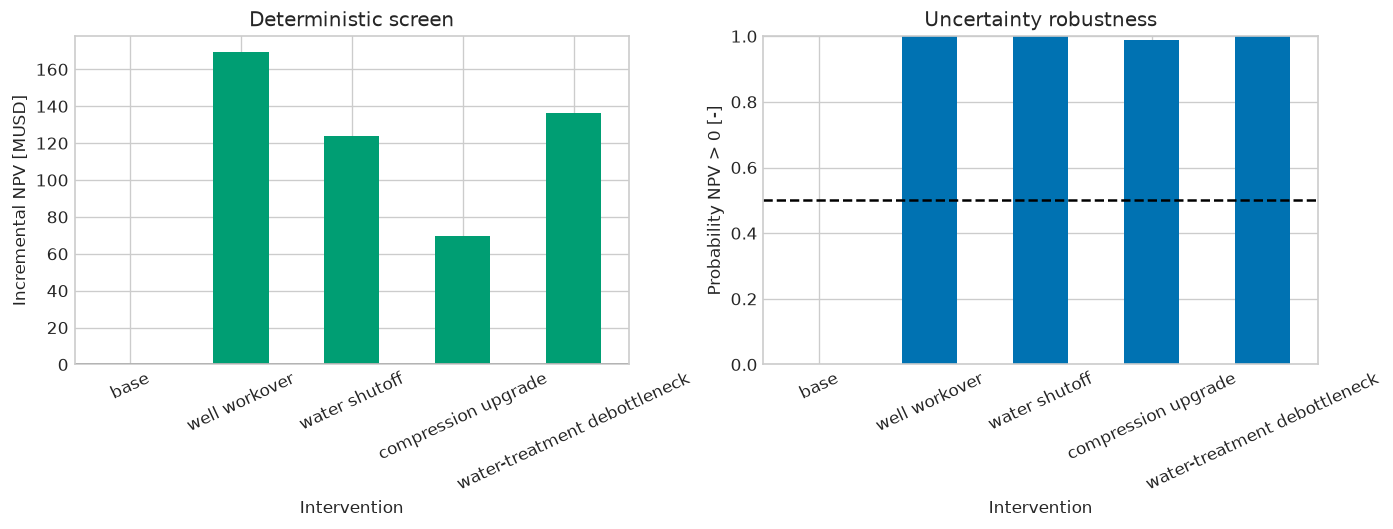

In [12]:
decision_figure, decision_axes = plt.subplots(
    1,
    2,
    figsize=(11.5, 4.3),
    constrained_layout=True,
)
economics.plot.bar(
    x="case",
    y="incremental_NPV_MUSD",
    ax=decision_axes[0],
    color="#009E73",
    legend=False,
)
decision_axes[0].axhline(0.0, color="black")
decision_axes[0].set(
    xlabel="Intervention",
    ylabel="Incremental NPV [MUSD]",
    title="Deterministic screen",
)
decision_table.plot.bar(
    x="case",
    y="probability_positive",
    ax=decision_axes[1],
    color="#0072B2",
    legend=False,
)
decision_axes[1].axhline(0.5, color="black", linestyle="--")
decision_axes[1].set(
    xlabel="Intervention",
    ylabel="Probability NPV > 0 [-]",
    title="Uncertainty robustness",
    ylim=(0.0, 1.0),
)
for axis in decision_axes:
    axis.tick_params(axis="x", rotation=25)
plt.show()


## 8. Data acquisition, assurance, and decision gates

A result is promoted only when the evidence needed for that decision
exists. The matrix distinguishes data QC, model calibration,
integrated forecast, facility assurance, commercial evaluation, and
decommissioning. Gaps become an acquisition or model-improvement
plan rather than being hidden in a deterministic number.


In [13]:
gate_matrix = pd.DataFrame(
    {
        "gate": [
            "G0 Marketplace data acceptance",
            "G1 geoscience and static uncertainty",
            "G2 PVT and reservoir history match",
            "G3 wells, SURF, and flow assurance",
            "G4 facilities and safeguarding",
            "G5 integrated economics and decision",
            "G6 late life and decommissioning",
        ],
        "minimum_evidence": [
            "manifest, licence, digests, units, well identifiers",
            "seismic tie, faults, contacts, realizations, STOIIP range",
            "lab PVT, SCAL, pressure, rates, OPM convergence and residuals",
            "tests, trajectories, completions, VLP, terrain and cooldown",
            "as-built topology, capacities, control, relief, emissions",
            "constraint graph, availability, uncertainty, fiscal basis",
            "cessation criteria, plugging, removal, monitoring and cost",
        ],
        "fallback_state": [
            "interface demonstrated",
            "synthetic truth demonstrated",
            "screening model demonstrated",
            "screening model demonstrated",
            "steady-state teaching model demonstrated",
            "screening decision model demonstrated",
            "scope only",
        ],
    }
)
display(gate_matrix)


,gate,minimum_evidence,fallback_state
0,G0 Marketplace data acceptance,"manifest, licence, digests, units, well identi...",interface demonstrated
1,G1 geoscience and static uncertainty,"seismic tie, faults, contacts, realizations, S...",synthetic truth demonstrated
2,G2 PVT and reservoir history match,"lab PVT, SCAL, pressure, rates, OPM convergenc...",screening model demonstrated
3,"G3 wells, SURF, and flow assurance","tests, trajectories, completions, VLP, terrain...",screening model demonstrated
4,G4 facilities and safeguarding,"as-built topology, capacities, control, relief...",steady-state teaching model demonstrated
5,G5 integrated economics and decision,"constraint graph, availability, uncertainty, f...",screening decision model demonstrated
6,G6 late life and decommissioning,"cessation criteria, plugging, removal, monitor...",scope only


In [14]:
preferred_case = (
    decision_table.sort_values(
        ["probability_positive", "P50_incremental_NPV_MUSD"],
        ascending=False,
    )
    .iloc[0]
    .to_dict()
)
final_contract_path = vc.write_contract(
    work_dir / "05_integrated_field_decision.json",
    {
        "discipline": "integrated-field-evaluation",
        "data_status": (
            "MEASURED_VOLVE"
            if source.measured_data_loaded
            else "DEMONSTRATION_FALLBACK"
        ),
        "active_constraint_counts": constraint_counts.to_dict(),
        "history_diagnostics": diagnostics.to_dict("records"),
        "economics": economics.to_dict("records"),
        "uncertainty_decisions": decision_table.to_dict("records"),
        "screening_preferred_case": preferred_case,
        "decision_status": (
            "requires measured Marketplace acceptance and discipline review"
        ),
        "limitations": [
            "fallback data unless Marketplace mode is run",
            "screening constraints and economics",
            "not reserves, investment, safety, or decommissioning approval",
        ],
    },
    source,
)
print(json.dumps(preferred_case, indent=2))
print(final_contract_path)


{
  "case": "well workover",
  "P10_incremental_NPV_MUSD": 103.22985676507489,
  "P50_incremental_NPV_MUSD": 175.53834542010486,
  "P90_incremental_NPV_MUSD": 264.48914640705794,
  "probability_positive": 1.0
}
/workspace/scratch/95ecac0092cf/neqsim-colab-volve/notebooks/fielddevelopment/volve/work/05_integrated_field_decision.json


In [15]:
checks = {
    "contracts use one schema": (
        registry_table.empty
        or registry_table["schema_version"].nunique() == 1
    ),
    "history rates non-negative": bool(
        field[
            ["oil_rate_Sm3_day", "gas_rate_Sm3_day", "water_rate_Sm3_day"]
        ]
        .ge(0.0)
        .all()
        .all()
    ),
    "integrated capacity finite": np.isfinite(
        field["integrated_capacity_Sm3_day"]
    ).all(),
    "constraints are named": bool(
        field["active_constraint"].isin(constraint_names).all()
    ),
    "deferred oil non-negative": bool(
        field["deferred_oil_Sm3_day"].ge(0.0).all()
    ),
    "economic outputs finite": np.isfinite(
        economics.select_dtypes(include=[np.number]).to_numpy()
    ).all(),
    "probabilities physical": bool(
        decision_table["probability_positive"].between(0.0, 1.0).all()
    ),
    "seven decision gates present": len(gate_matrix) == 7,
    "final handoff exists": final_contract_path.is_file(),
}
validation = pd.DataFrame(
    {"check": checks.keys(), "passed": checks.values()}
)
display(validation)
if not validation["passed"].all():
    raise AssertionError(validation.loc[~validation["passed"], "check"].tolist())
print(f"All {len(checks)} integrated field checks passed.")


All 9 integrated field checks passed.


,check,passed
0,contracts use one schema,True
1,history rates non-negative,True
2,integrated capacity finite,True
3,constraints are named,True
4,deferred oil non-negative,True
5,economic outputs finite,True
6,probabilities physical,True
7,seven decision gates present,True
8,final handoff exists,True


## Final interpretation

The five notebooks show how the Volve Data Village can anchor one
connected field evaluation while respecting discipline boundaries:
seismic and logs constrain the static model; NeqSim PVT feeds OPM
Flow; reservoir states feed wells and SURF; the arrival envelope
feeds NeqSim facilities; and the integrated twin identifies active
constraints, uncertainty, interventions, emissions, economics, and
the next evidence required.

The saved fallback run proves the code path and visualization
quality. A result becomes a Volve evaluation only after the
Marketplace asset paths are selected, digested, parsed, executed,
reconciled, and reviewed through all acceptance gates.
